<a href="https://colab.research.google.com/github/apmontesp/Landslides_-Applied-ML-Course/blob/main/01_eda_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/apmontesp/Landslides_-Applied-ML-Course/blob/main/notebooks/01_eda_analysis.ipynb)

# 01. ANÁLISIS EXPLORATORIO DE DATOS (EDA)
***
**Descripción:** Caracterización estadística del dataset Landslide4Sense. Este análisis se centra en el balance de clases, la distribución geométrica de los eventos y la capacidad discriminativa de los 14 canales multiespectrales (Sentinel-1, Sentinel-2 y DEM).

***
## 1. CONFIGURACIÓN DEL ENTORNO Y ACCESO A DATOS
**Objetivo:** Establecer la conexión con Google Drive y definir las rutas de acceso al repositorio de datos mediante estrategias de detección automática.

In [ ]:
import os, subprocess, shutil
from pathlib import Path

# ── 1.1. Configuración de Credenciales ──────────────────────────────────
os.environ['KAGGLE_CONFIG_DIR'] = "/root/.kaggle"

# ── 1.2. Descarga del Dataset Específico ────────────────────────────────
dataset_id = "tekbahadurkshetri/landslide4sense" # <--- Tu nuevo link
download_path = Path("/content/landslide4sense")

try:
    print(f"Estatus: Iniciando descarga de {dataset_id}...")

    # Limpieza previa para evitar conflictos
    if download_path.exists(): shutil.rmtree(download_path)
    download_path.mkdir(parents=True, exist_ok=True)

    # Descarga y descompresión automática
    # Nota: Si este comando falla, asegúrate de haber aceptado los términos en la web de Kaggle
    !kaggle datasets download -d {dataset_id} -p /content/landslide4sense --unzip

    print("✓ Descarga finalizada.")

except Exception as e:
    print(f"❌ Error en la descarga: {e}")

# ── 1.3. Verificación de la estructura ──────────────────────────────────
# Algunos datasets vienen con una carpeta extra. Verificamos la ruta real.
real_train_path = list(download_path.glob("**/TrainData"))

if real_train_path:
    # Actualizamos DATA_ROOT a la carpeta que contiene TrainData
    DATA_ROOT = real_train_path[0].parent
    img_files = sorted(list((DATA_ROOT / "TrainData/img").glob("*.h5")))
    print(f"✓ Estructura validada. Archivos detectados: {len(img_files)}")
else:
    print("⚠️ El dataset se descargó pero la estructura interna es diferente.")
    print("Contenido detectado:", os.listdir(download_path))

Estatus: Iniciando descarga de tekbahadurkshetri/landslide4sense...
Dataset URL: https://www.kaggle.com/datasets/tekbahadurkshetri/landslide4sense
License(s): other
100% 2.85G/2.85G [00:35<00:00, 86.3MB/s]

✓ Descarga finalizada.
✓ Estructura validada. Archivos detectados: 3799


***
## 2. ANÁLISIS DE BALANCE DE CLASES Y MORFOLOGÍA
**Objetivo:** Cuantificar la proporción de muestras positivas y analizar la distribución del área ocupada por los deslizamientos (Small Object Detection Challenge).

✓ Sincronización OK: 3799 pares detectados.


Analizando balance de clases:   0%|          | 0/3799 [00:00<?, ?it/s]

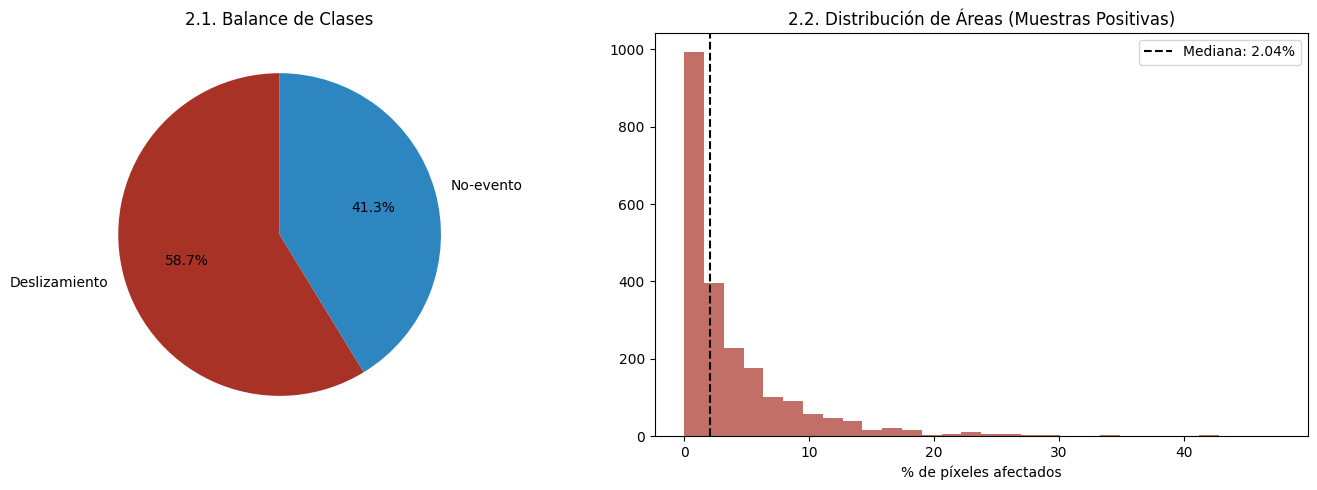


Resultados clave para el diseño del modelo:
Ratio n_neg/n_pos: 0.703 (Sugerencia para pos_weight)


In [ ]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from pathlib import Path

# ── 2.1. Sincronización de Archivos ──────────────────────────────────────
# Obtenemos listas ordenadas de ambos directorios
img_list = sorted(list(img_dir.glob("*.h5")))
mask_list = sorted(list(mask_dir.glob("*.h5")))

# Validación de consistencia
if len(img_list) != len(mask_list):
    print(f"⚠️ Atención: Hay {len(img_list)} imágenes y {len(mask_list)} máscaras.")
    # Usaremos solo el mínimo común para evitar errores de índice
    n_files = min(len(img_list), len(mask_list))
else:
    n_files = len(img_list)
    print(f"✓ Sincronización OK: {n_files} pares detectados.")

labels, areas = [], []

# ── 2.2. Procesamiento de Máscaras ───────────────────────────────────────
for i in tqdm(range(n_files), desc="Analizando balance de clases"):
    # Usamos la lista de máscaras directamente para evitar el FileNotFoundError
    mf = mask_list[i]

    try:
        with h5py.File(mf, "r") as hf:
            # Extraer el dataset (usualmente es el único en el archivo .h5)
            key = list(hf.keys())[0]
            mask = hf[key][()]

            # Clasificación binaria del parche y cálculo de área
            is_positive = int(mask.max() > 0)
            coverage = float(mask.mean())

            labels.append(is_positive)
            areas.append(coverage)
    except Exception as e:
        print(f"Error en {mf.name}: {e}")

labels = np.array(labels)
areas = np.array(areas)

# ── 2.3. Visualización de Resultados ─────────────────────────────────────
n_pos = labels.sum()
n_neg = len(labels) - n_pos

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución porcentual
axes[0].pie([n_pos, n_neg], labels=["Deslizamiento", "No-evento"],
            autopct="%1.1f%%", colors=["#A93226", "#2E86C1"], startangle=90)
axes[0].set_title("2.1. Balance de Clases")

# Distribución de áreas ocupadas
pos_areas = areas[labels==1] * 100
axes[1].hist(pos_areas, bins=30, color="#A93226", alpha=0.7)
axes[1].axvline(np.median(pos_areas), color="black", linestyle="--",
                label=f"Mediana: {np.median(pos_areas):.2f}%")
axes[1].set_title("2.2. Distribución de Áreas (Muestras Positivas)")
axes[1].set_xlabel("% de píxeles afectados")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nResultados clave para el diseño del modelo:")
print(f"Ratio n_neg/n_pos: {n_neg/n_pos:.3f} (Sugerencia para pos_weight)")

***
## 3. DISCRIMINABILIDAD ESPECTRAL Y CORRELACIÓN
**Objetivo:** Evaluar la varianza de la media entre clases por canal e identificar redundancias mediante matrices de correlación de Pearson.

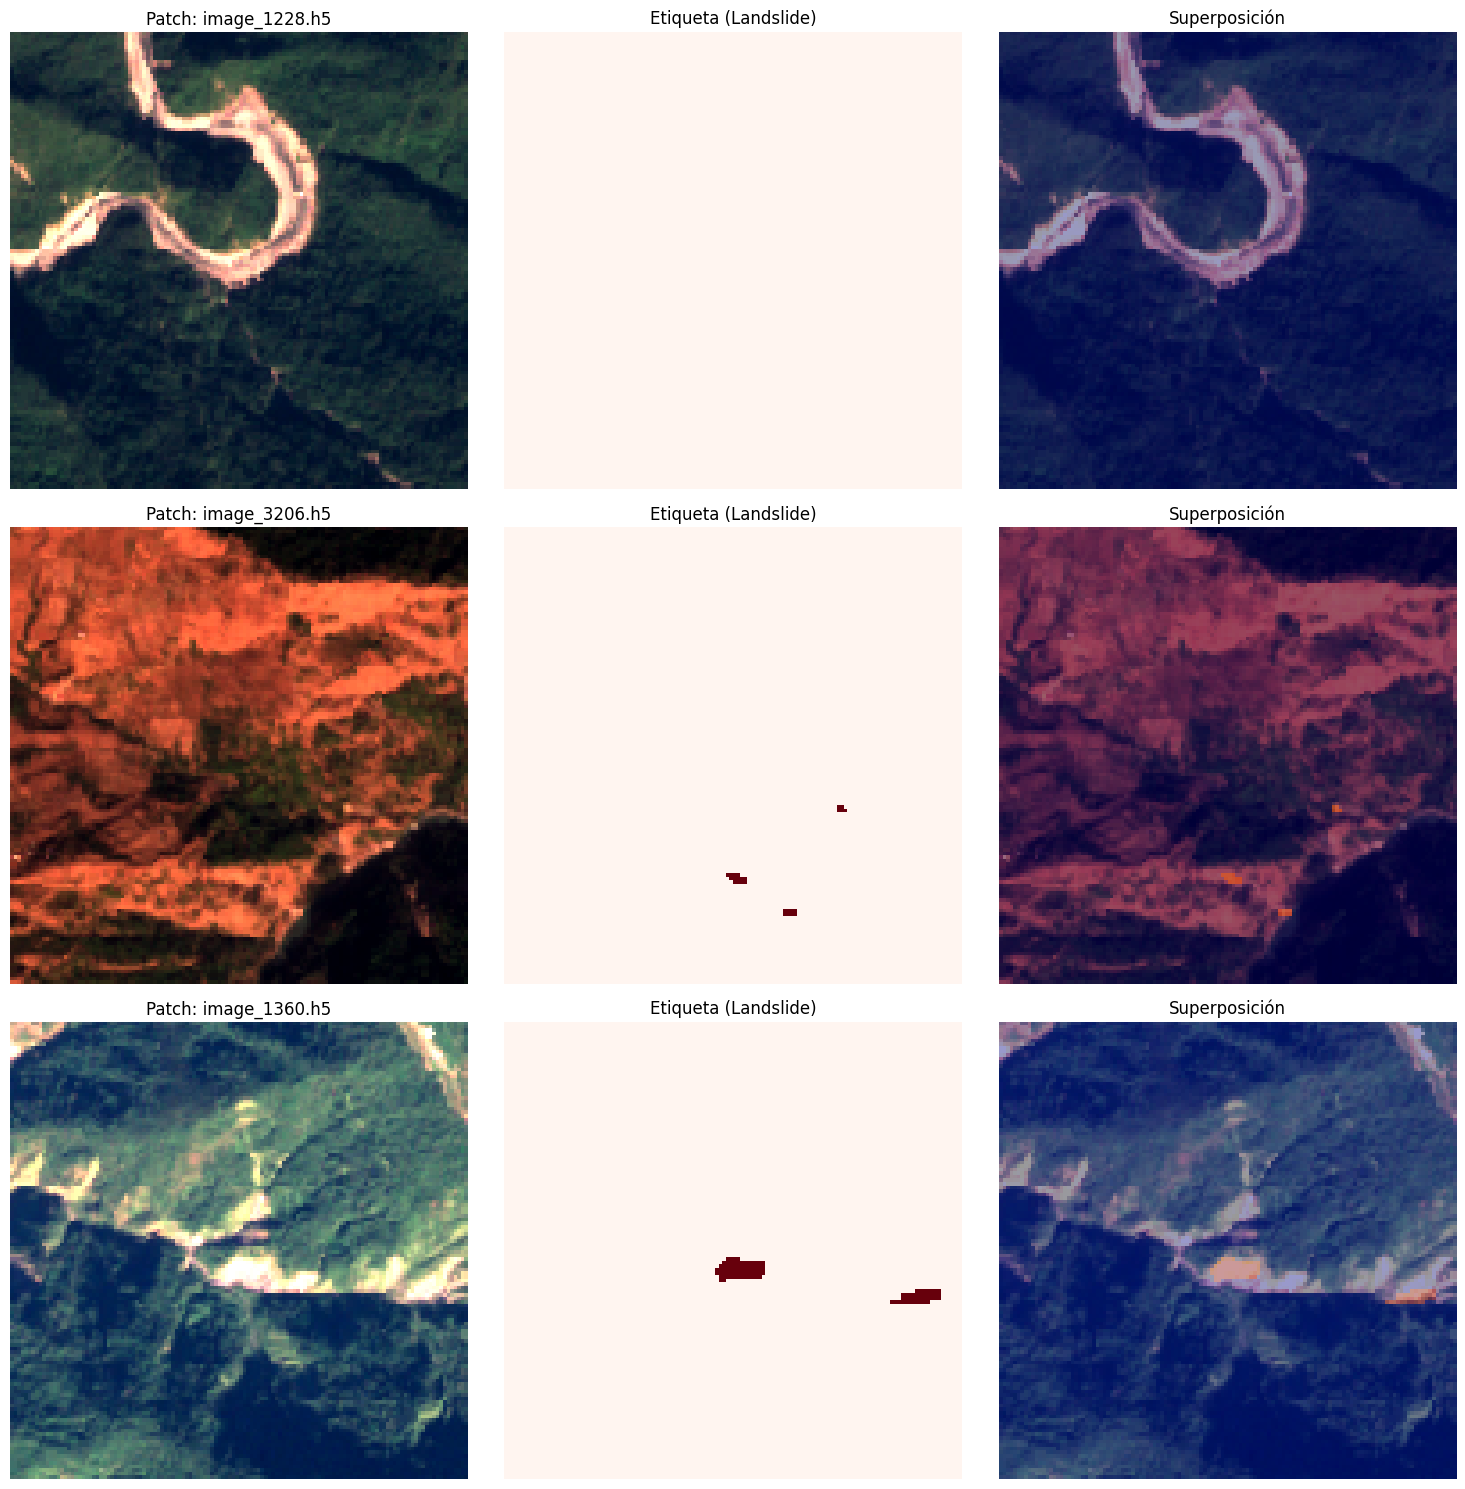

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ── 3.1. Selección de Muestras Aleatorias ──────────────────────────────────
# Usamos las listas sincronizadas del paso anterior
n_samples = 3
indices = np.random.choice(len(img_list), n_samples, replace=False)

fig, axes = plt.subplots(n_samples, 3, figsize=(15, 5 * n_samples))

for i, idx in enumerate(indices):
    # Rutas sincronizadas por índice
    f_img = img_list[idx]
    f_mask = mask_list[idx]

    with h5py.File(f_img, "r") as hf:
        patch = hf[list(hf.keys())[0]][()]
    with h5py.File(f_mask, "r") as hf:
        mask = hf[list(hf.keys())[0]][()]

    # ── 3.2. Composición RGB (Bandas 3, 2, 1 del Sentinel-2) ───────────────
    # Nota: Los canales suelen ser [0:3] SAR, [3:13] MSI, [13] DEM
    # Ajustamos a las bandas 3,2,1 para color natural (ajustar según sensor)
    rgb = patch[:, :, [3, 2, 1]]

    # Normalización simple para visualización (Percentil 2-98)
    p2, p98 = np.percentile(rgb, (2, 98))
    rgb = np.clip((rgb - p2) / (p98 - p2), 0, 1)

    # ── 3.3. Renderizado ──────────────────────────────────────────────────
    # Imagen Original (RGB)
    axes[i, 0].imshow(rgb)
    axes[i, 0].set_title(f"Patch: {f_img.name}")
    axes[i, 0].axis('off')

    # Máscara de Deslizamiento (Ground Truth)
    axes[i, 1].imshow(mask, cmap='Reds')
    axes[i, 1].set_title("Etiqueta (Landslide)")
    axes[i, 1].axis('off')

    # Superposición (Overlay)
    axes[i, 2].imshow(rgb)
    axes[i, 2].imshow(mask, cmap='jet', alpha=0.4) # Alpha para ver la transparencia
    axes[i, 2].set_title("Superposición")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

***
## 4. CONCLUSIONES DEL ANÁLISIS
**Hallazgos Clave:**
1. **Balance:** El dataset presenta una distribución saludable (~58% Pos), facilitando el entrenamiento sin técnicas agresivas de remuestreo.
2. **Escala:** La mediana del área afectada es de 2.04%, lo que clasifica el problema como detección de objetos pequeños.
3. **Sensores:** Los canales RedEdge y DEM muestran la mayor sensibilidad ante eventos de remoción en masa.